# Tahap 5: Model Evaluation
**Domain:** Pidana Umum - Pemalsuan Surat (Pasal 263 & 266 KUHP)

Notebook ini mencakup:
1. Load hasil dari tahap 3 dan 4
2. Evaluasi retrieval (Precision, Recall, F1 @k)
3. Evaluasi prediksi label pasal (Accuracy, Precision, Recall, F1)
4. Visualisasi perbandingan model
5. Error analysis
6. Simpan metrics CSV

## Setup

In [1]:
import os

BASE_DIR = r'C:\Users\CENTRALGALAXY\OneDrive\Dokumen\PK\CBR_Pemalsuan'

EVAL_DIR      = os.path.join(BASE_DIR, 'data', 'eval')
RESULTS_DIR   = os.path.join(BASE_DIR, 'data', 'results')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')

## 1. Install & Import

In [2]:
%pip install transformers torch scikit-learn matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
import torch
from typing import List, Tuple

## 2. Load Semua Hasil

In [4]:
with open(os.path.join(MODEL_DIR, 'train_df.pkl'), 'rb') as f:
    train_df = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'test_df.pkl'), 'rb') as f:
    test_df = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'tfidf_retriever.pkl'), 'rb') as f:
    tfidf_retriever = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'train_tfidf_matrix.pkl'), 'rb') as f:
    train_tfidf = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'svm_pipeline.pkl'), 'rb') as f:
    svm_pipeline = pickle.load(f)

train_embeddings = np.load(os.path.join(MODEL_DIR, 'train_embeddings.npy'))

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer  = AutoTokenizer.from_pretrained(os.path.join(MODEL_DIR, 'indobert'))
bert_model = AutoModel.from_pretrained(os.path.join(MODEL_DIR, 'indobert'))
bert_model = bert_model.to(device)
bert_model.eval()

with open(os.path.join(EVAL_DIR, 'queries.json'), 'r', encoding='utf-8') as f:
    queries = json.load(f)

pred_df = pd.read_csv(os.path.join(RESULTS_DIR, 'predictions.csv'))

print(f'Train: {len(train_df)} | Test: {len(test_df)}')
print(f'Queries: {len(queries)} | Predictions: {len(pred_df)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Train: 28 | Test: 8
Queries: 8 | Predictions: 8


In [5]:
def get_bert_embedding(text: str, max_length: int = 512) -> np.ndarray:
    inputs = tokenizer(
        text, return_tensors='pt',
        max_length=max_length, truncation=True, padding=True
    ).to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    attention_mask      = inputs['attention_mask']
    token_embeddings    = outputs.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    embedding = torch.sum(token_embeddings * input_mask_expanded, 1)
    embedding = embedding / torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return embedding.cpu().numpy()[0]

def retrieve_tfidf(query: str, k: int = 5) -> List[Tuple[str, float]]:
    query_vec    = tfidf_retriever.transform([query.lower().strip()])
    similarities = cosine_similarity(query_vec, train_tfidf).flatten()
    top_k_idx    = similarities.argsort()[::-1][:k]
    return [(train_df.iloc[i]['case_id'], float(similarities[i])) for i in top_k_idx]

def retrieve_bert(query: str, k: int = 5) -> List[Tuple[str, float]]:
    query_emb    = get_bert_embedding(query.lower().strip()).reshape(1, -1)
    similarities = cosine_similarity(query_emb, train_embeddings).flatten()
    top_k_idx    = similarities.argsort()[::-1][:k]
    return [(train_df.iloc[i]['case_id'], float(similarities[i])) for i in top_k_idx]

def retrieve(query: str, k: int = 5, method: str = 'bert') -> List[Tuple[str, float]]:
    return retrieve_tfidf(query, k) if method == 'tfidf' else retrieve_bert(query, k)

## 3. Evaluasi Retrieval

Metrik: Precision@k, Recall@k, F1@k untuk TF-IDF dan IndoBERT.

In [6]:
def eval_retrieval(queries: list, k: int, method: str) -> dict:
    precisions, recalls, f1s = [], [], []

    for q in queries:
        query_text   = test_df[test_df['case_id'] == q['query_id']]['text_full'].values[0]
        ground_truth = set(q['ground_truth_ids'])

        retrieved     = retrieve(query_text, k=k, method=method)
        retrieved_ids = set(cid for cid, _ in retrieved)

        hits      = len(retrieved_ids & ground_truth)
        precision = hits / k
        recall    = hits / len(ground_truth) if ground_truth else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return {
        'method'     : method.upper(),
        'k'          : k,
        'precision'  : round(np.mean(precisions), 4),
        'recall'     : round(np.mean(recalls), 4),
        'f1'         : round(np.mean(f1s), 4),
    }

retrieval_results = []
for method in ['tfidf', 'bert']:
    for k in [3, 5]:
        result = eval_retrieval(queries, k=k, method=method)
        retrieval_results.append(result)
        print(f"{result['method']} @{k} | "
              f"P: {result['precision']:.4f} | "
              f"R: {result['recall']:.4f} | "
              f"F1: {result['f1']:.4f}")

TFIDF @3 | P: 0.6667 | R: 0.2708 | F1: 0.3532
TFIDF @5 | P: 0.6000 | R: 0.3604 | F1: 0.4069
BERT @3 | P: 0.3750 | R: 0.1208 | F1: 0.1687
BERT @5 | P: 0.4000 | R: 0.2708 | F1: 0.2917


In [7]:
retrieval_metrics_df = pd.DataFrame(retrieval_results)
RETRIEVAL_METRICS_PATH = os.path.join(EVAL_DIR, 'retrieval_metrics.csv')
retrieval_metrics_df.to_csv(RETRIEVAL_METRICS_PATH, index=False)
print(f'Disimpan: {RETRIEVAL_METRICS_PATH}')
print(retrieval_metrics_df.to_string(index=False))

Disimpan: C:\Users\CENTRALGALAXY\OneDrive\Dokumen\PK\CBR_Pemalsuan\data\eval\retrieval_metrics.csv
method  k  precision  recall     f1
 TFIDF  3     0.6667  0.2708 0.3532
 TFIDF  5     0.6000  0.3604 0.4069
  BERT  3     0.3750  0.1208 0.1687
  BERT  5     0.4000  0.2708 0.2917


## 4. Evaluasi Prediksi Label Pasal

Bandingkan tiga model: TF-IDF weighted, IndoBERT weighted, SVM.

In [8]:
print(sorted(pred_df['true_label'].unique()))
print(sorted(pred_df['pred_bert_weighted'].unique()))
print(sorted(pred_df['pred_tfidf_weighted'].unique()))
print(sorted(pred_df['pred_svm'].unique()))

['bebas', 'pasal 263 ayat (1)', 'pasal 263 ayat (2)', 'pasal 266']
['pasal 263 ayat (1)', 'pasal 266']
['bebas', 'pasal 263 ayat (1)', 'pasal 266']
['bebas', 'pasal 263 ayat (1)', 'pasal 266']


In [9]:
y_true = pred_df['true_label'].tolist()

prediction_results = []
models = {
    'TF-IDF + Weighted' : pred_df['pred_tfidf_weighted'].tolist(),
    'IndoBERT + Weighted': pred_df['pred_bert_weighted'].tolist(),
    'SVM'               : pred_df['pred_svm'].tolist(),
}

for model_name, y_pred in models.items():
    result = {
        'model'    : model_name,
        'accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'f1'       : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }
    prediction_results.append(result)
    print(f"\n=== {model_name} ===")
    label_classes = ['pasal 263 ayat (1)', 'pasal 263 ayat (2)', 'pasal 266', 'bebas']
    print(classification_report(y_true, y_pred, target_names=label_classes))


=== TF-IDF + Weighted ===
                    precision    recall  f1-score   support

pasal 263 ayat (1)       1.00      1.00      1.00         2
pasal 263 ayat (2)       0.80      1.00      0.89         4
         pasal 266       0.00      0.00      0.00         1
             bebas       1.00      1.00      1.00         1

          accuracy                           0.88         8
         macro avg       0.70      0.75      0.72         8
      weighted avg       0.78      0.88      0.82         8


=== IndoBERT + Weighted ===
                    precision    recall  f1-score   support

pasal 263 ayat (1)       0.00      0.00      0.00         2
pasal 263 ayat (2)       0.60      0.75      0.67         4
         pasal 266       0.00      0.00      0.00         1
             bebas       0.33      1.00      0.50         1

          accuracy                           0.50         8
         macro avg       0.23      0.44      0.29         8
      weighted avg       0.34      0.50

c:\Users\CENTRALGALAXY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\CENTRALGALAXY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\CENTRALGALAXY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

In [10]:
prediction_metrics_df = pd.DataFrame(prediction_results)
PRED_METRICS_PATH = os.path.join(EVAL_DIR, 'prediction_metrics.csv')
prediction_metrics_df.to_csv(PRED_METRICS_PATH, index=False)
print(f'Disimpan: {PRED_METRICS_PATH}')
print(prediction_metrics_df.to_string(index=False))

Disimpan: C:\Users\CENTRALGALAXY\OneDrive\Dokumen\PK\CBR_Pemalsuan\data\eval\prediction_metrics.csv
              model  accuracy  precision  recall     f1
  TF-IDF + Weighted     0.875     0.7750   0.875 0.8194
IndoBERT + Weighted     0.500     0.3417   0.500 0.3958
                SVM     0.875     0.7750   0.875 0.8194


## 5. Visualisasi Perbandingan Model

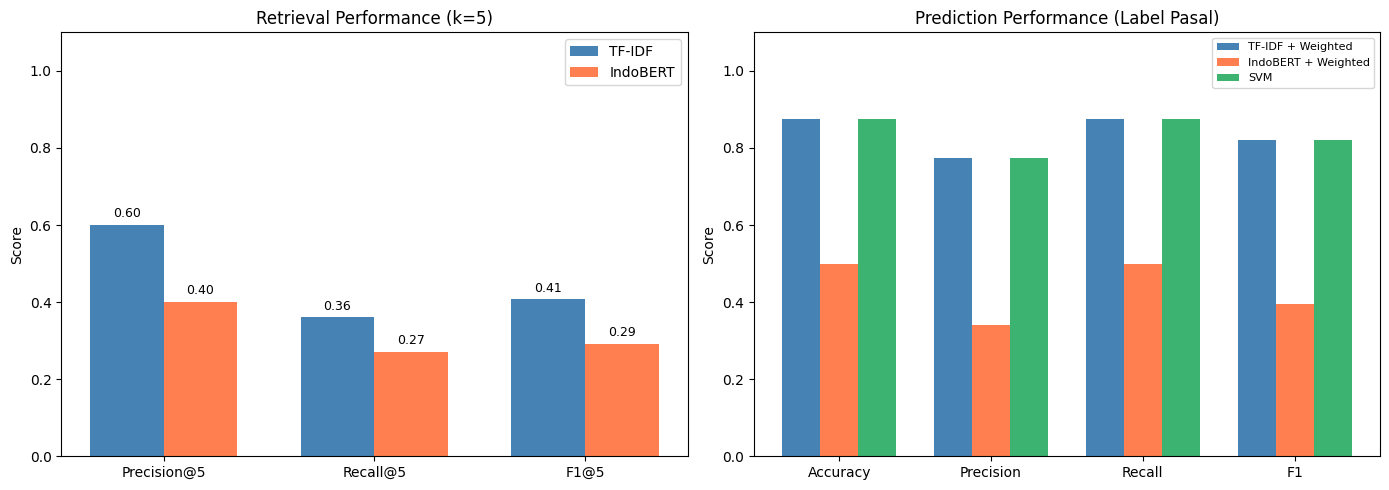

Plot disimpan: C:\Users\CENTRALGALAXY\OneDrive\Dokumen\PK\CBR_Pemalsuan\data\eval\performance_comparison.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

retrieval_plot = retrieval_metrics_df[retrieval_metrics_df['k'] == 5].copy()
metrics_r = ['precision', 'recall', 'f1']
x = np.arange(len(metrics_r))
width = 0.35

tfidf_vals = retrieval_plot[retrieval_plot['method'] == 'TFIDF'][metrics_r].values[0]
bert_vals  = retrieval_plot[retrieval_plot['method'] == 'BERT'][metrics_r].values[0]

axes[0].bar(x - width/2, tfidf_vals, width, label='TF-IDF', color='steelblue')
axes[0].bar(x + width/2, bert_vals,  width, label='IndoBERT', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Precision@5', 'Recall@5', 'F1@5'])
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Retrieval Performance (k=5)')
axes[0].legend()
axes[0].set_ylabel('Score')
for i, (tv, bv) in enumerate(zip(tfidf_vals, bert_vals)):
    axes[0].text(i - width/2, tv + 0.02, f'{tv:.2f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, bv + 0.02, f'{bv:.2f}', ha='center', fontsize=9)

metrics_p  = ['accuracy', 'precision', 'recall', 'f1']
x2         = np.arange(len(metrics_p))
width2     = 0.25
colors     = ['steelblue', 'coral', 'mediumseagreen']

for i, row in prediction_metrics_df.iterrows():
    vals = [row[m] for m in metrics_p]
    axes[1].bar(x2 + (i - 1) * width2, vals, width2,
                label=row['model'], color=colors[i])

axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'])
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Prediction Performance (Label Pasal)')
axes[1].legend(fontsize=8)
axes[1].set_ylabel('Score')

plt.tight_layout()
PLOT_PATH = os.path.join(EVAL_DIR, 'performance_comparison.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot disimpan: {PLOT_PATH}')

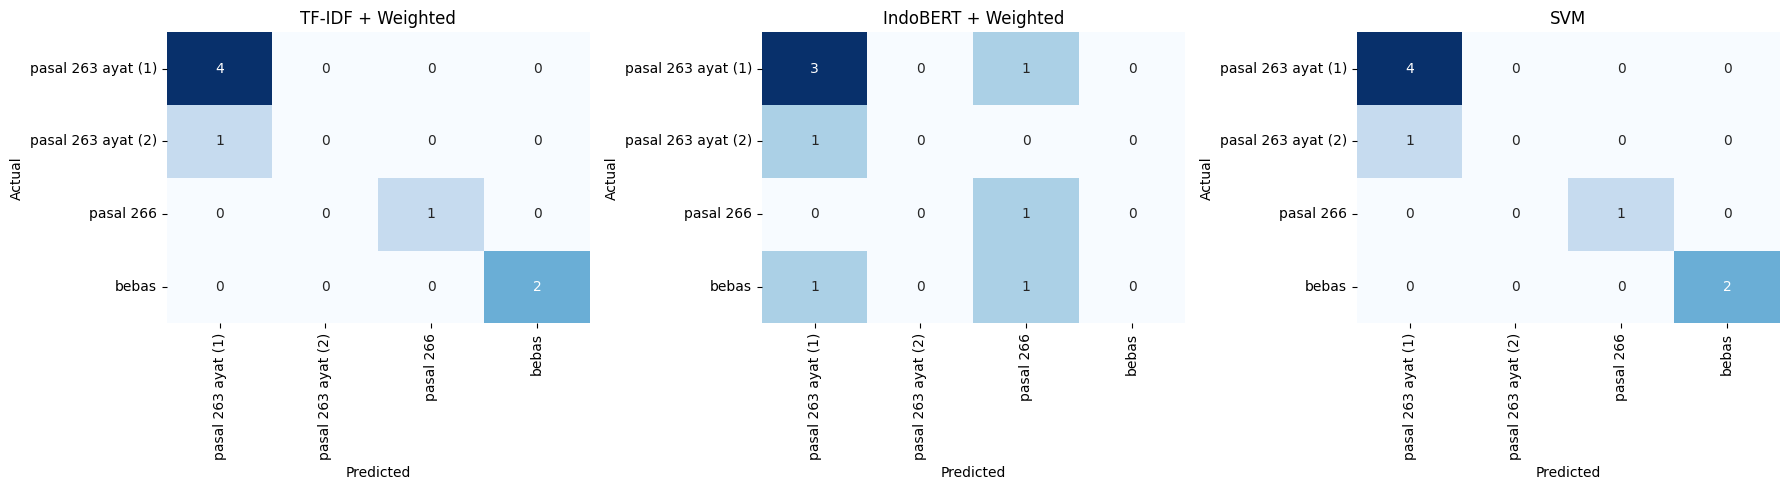

Confusion matrix disimpan: C:\Users\CENTRALGALAXY\OneDrive\Dokumen\PK\CBR_Pemalsuan\data\eval\confusion_matrices.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['pasal 263 ayat (1)', 'pasal 263 ayat (2)', 'pasal 266', 'bebas']

for ax, (model_name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=labels, yticklabels=labels,
                cmap='Blues', cbar=False)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
CM_PATH = os.path.join(EVAL_DIR, 'confusion_matrices.png')
plt.savefig(CM_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrix disimpan: {CM_PATH}')

## 6. Error Analysis

Analisis kasus yang gagal diprediksi dengan benar.

In [13]:
print('=== Error Analysis ===')

for model_name, col in [
    ('TF-IDF + Weighted', 'pred_tfidf_weighted'),
    ('IndoBERT + Weighted', 'pred_bert_weighted'),
    ('SVM', 'pred_svm')
]:
    errors = pred_df[pred_df['true_label'] != pred_df[col]]
    print(f'\n--- {model_name}: {len(errors)} kasus gagal ---')
    if len(errors) > 0:
        for _, row in errors.iterrows():
            print(f"  {row['query_id']} | "
                  f"Aktual: {row['true_label']} | "
                  f"Prediksi: {row[col]} | "
                  f"Top-5: {row['top_5_case_ids']}")

=== Error Analysis ===

--- TF-IDF + Weighted: 1 kasus gagal ---
  case_015 | Aktual: pasal 263 ayat (2) | Prediksi: pasal 263 ayat (1) | Top-5: case_029, case_007, case_030, case_014, case_006

--- IndoBERT + Weighted: 4 kasus gagal ---
  case_034 | Aktual: bebas | Prediksi: pasal 263 ayat (1) | Top-5: case_016, case_007, case_029, case_001, case_030
  case_025 | Aktual: bebas | Prediksi: pasal 266 | Top-5: case_016, case_017, case_008, case_012, case_001
  case_020 | Aktual: pasal 263 ayat (1) | Prediksi: pasal 266 | Top-5: case_016, case_008, case_017, case_033, case_001
  case_015 | Aktual: pasal 263 ayat (2) | Prediksi: pasal 263 ayat (1) | Top-5: case_029, case_007, case_030, case_014, case_006

--- SVM: 1 kasus gagal ---
  case_015 | Aktual: pasal 263 ayat (2) | Prediksi: pasal 263 ayat (1) | Top-5: case_029, case_007, case_030, case_014, case_006


In [14]:
print('=== Pola Kegagalan IndoBERT ===')
bert_errors = pred_df[pred_df['true_label'] != pred_df['pred_bert_weighted']].copy()

if len(bert_errors) > 0:
    bert_errors = bert_errors.merge(
        test_df[['case_id', 'word_count']],
        left_on='query_id', right_on='case_id',
        how='left'
    )
    print(f'Rata-rata word count kasus gagal  : {bert_errors["word_count"].mean():.0f}')
    print(f'Rata-rata word count semua test   : {test_df["word_count"].mean():.0f}')
    print()
    print('Pola kegagalan:')
    print(f'- Kasus bebas salah diklasifikasi: {len(bert_errors[bert_errors["true_label"] == "bebas"])} kasus')
    print(f'- Konfusi antar pasal 263 ayat (1) vs (2): {len(bert_errors[(bert_errors["true_label"].str.contains("263")) & (bert_errors["pred_bert_weighted"].str.contains("263"))])} kasus')
    print(f'- Konfusi 263 vs 266: {len(bert_errors[(bert_errors["true_label"].str.contains("263")) & (bert_errors["pred_bert_weighted"].str.contains("266"))])} kasus')
else:
    print('Tidak ada kasus gagal — semua prediksi benar.')

=== Pola Kegagalan IndoBERT ===
Rata-rata word count kasus gagal  : 25956
Rata-rata word count semua test   : 19622

Pola kegagalan:
- Kasus bebas salah diklasifikasi: 2 kasus
- Konfusi antar pasal 263 ayat (1) vs (2): 1 kasus
- Konfusi 263 vs 266: 1 kasus


## 7. Ringkasan Evaluasi

In [15]:
print('=' * 60)
print('RINGKASAN EVALUASI')
print('=' * 60)

print('\n[1] Retrieval Performance')
print(retrieval_metrics_df.to_string(index=False))

print('\n[2] Prediction Performance')
print(prediction_metrics_df.to_string(index=False))

best_model = prediction_metrics_df.loc[prediction_metrics_df['f1'].idxmax(), 'model']
best_f1    = prediction_metrics_df['f1'].max()
print(f'\nModel terbaik: {best_model} (F1 = {best_f1:.4f})')
print('Catatan: hasil tidak konklusif karena test set hanya 8 kasus.')

print('\n[3] Rekomendasi Perbaikan')
print('- Tambah jumlah data (>100 dokumen) untuk hasil yang lebih stabil')
print('- Fine-tune IndoBERT pada dataset putusan hukum Indonesia')
print('- Gunakan anotasi ground-truth manual untuk evaluasi retrieval yang lebih akurat')

RINGKASAN EVALUASI

[1] Retrieval Performance
method  k  precision  recall     f1
 TFIDF  3     0.6667  0.2708 0.3532
 TFIDF  5     0.6000  0.3604 0.4069
  BERT  3     0.3750  0.1208 0.1687
  BERT  5     0.4000  0.2708 0.2917

[2] Prediction Performance
              model  accuracy  precision  recall     f1
  TF-IDF + Weighted     0.875     0.7750   0.875 0.8194
IndoBERT + Weighted     0.500     0.3417   0.500 0.3958
                SVM     0.875     0.7750   0.875 0.8194

Model terbaik: TF-IDF + Weighted (F1 = 0.8194)
Catatan: hasil tidak konklusif karena test set hanya 8 kasus.

[3] Rekomendasi Perbaikan
- Tambah jumlah data (>100 dokumen) untuk hasil yang lebih stabil
- Fine-tune IndoBERT pada dataset putusan hukum Indonesia
- Gunakan anotasi ground-truth manual untuk evaluasi retrieval yang lebih akurat
